# H2 End-to-End Pipeline: EDA → Preprocessing → Train → Evaluate

This notebook builds a full workflow for the FALCON H2 handwriting dataset (T5 participant): quick data peek, session/trial summary and optional caches, training the `HritikDecoder`, and evaluating WER/CER/latency locally. Data is expected under `data/h2`.

## 1) Setup Paths, Environment, and Imports

We'll import core libraries, set paths, and verify that `falcon_challenge` modules can be imported. If JAX/GPU isn't available, we default to CPU and disable large upfront allocations.

In [1]:
# Robust setup: paths, env, and imports

from pathlib import Path

import os

import sys

import json

import math

import numpy as np

import matplotlib.pyplot as plt

from tqdm import tqdm



# Force CPU for compatibility (METAL backend has experimental issues)

os.environ["JAX_PLATFORMS"] = "cpu"

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"



try:

    import jax

    import jax.numpy as jnp

    print(f"JAX devices: {jax.devices()} | backend: {jax.default_backend()}")

except Exception as e:

    print("Warning: JAX not available. Training/evaluation cells that require JAX will fail.")

    print(e)

    jax = None

    jnp = None



# Project-relative paths

project_root = Path.cwd()

data_root = project_root / "data" / "h2"

held_in_dir = data_root / "sub-T5-held-in-calib"

minival_dir = data_root / "sub-T5-held-in-minival"

held_out_dir = data_root / "sub-T5-held-out-calib"

preproc_out = project_root / "local_data" / "h2_preproc"

model_out = project_root / "local_data" / "hritik_h2"



for p in [preproc_out, model_out, project_root / "runs" / "hritik_h2"]:

    p.mkdir(parents=True, exist_ok=True)



try:

    import falcon_challenge

    from falcon_challenge.config import FalconTask, FalconConfig

    from falcon_challenge.dataloaders import load_nwb

    try:

        print("falcon_challenge version:", getattr(falcon_challenge, "__version__", "unknown"))

    except Exception:

        pass

except Exception as e:

    print("Error: falcon_challenge package is not importable from this environment.")

    print("Ensure you're running in the repo root and dependencies are installed.")

    raise



# Helper to decode an array of int codes to string (filter 0s)

def decode_target_codes(arr):

    return "".join(chr(int(c)) for c in arr if int(c) != 0)



JAX devices: [CpuDevice(id=0)] | backend: cpu
falcon_challenge version: unknown
falcon_challenge version: unknown


## 2) Quick Peek at H2 Files and Shapes

We list a few files per split and load one to inspect shapes: spikes `(T×C)`, number of trials from `trial_done`, and number of valid timesteps from `eval_mask`. We also decode the first target to a string.

In [2]:
from data_demos.h2_eda_preprocessing import infer_session_from_name



def list_some_files(path: Path, n=3):

    return [str(p) for p in sorted(path.glob("*.nwb"))[:n]]



print("Held-in calib examples:", list_some_files(held_in_dir))

print("Minival examples:", list_some_files(minival_dir))

print("Held-out calib examples:", list_some_files(held_out_dir))



# Load one file per split if available

for split_name, p in [("sub-T5-held-in-calib", held_in_dir), ("sub-T5-held-in-minival", minival_dir), ("sub-T5-held-out-calib", held_out_dir)]:

    files = sorted(p.glob("*.nwb"))

    if not files:

        print(f"No files found for {split_name} at {p}")

        continue

    fn = files[0]

    spikes, targets, trial_done, eval_mask = load_nwb(fn, dataset=FalconTask.h2)

    T, C = spikes.shape

    n_trials = int(np.sum(trial_done))

    n_valid = int(np.sum(eval_mask)) if eval_mask is not None else 0

    first_text = decode_target_codes(targets[0]) if len(targets) > 0 else ""

    session = infer_session_from_name(fn.stem)

    print(f"[{split_name}] {fn.name}: T={T}, C={C}, trials={n_trials}, valid_ts={n_valid}, first_text='{first_text}', session='{session}'")


Held-in calib examples: ['/Users/hritikarasu/Developer/falcon-challenge/data/h2/sub-T5-held-in-calib/sub-T5-held-in-calib_ses-20220518.nwb', '/Users/hritikarasu/Developer/falcon-challenge/data/h2/sub-T5-held-in-calib/sub-T5-held-in-calib_ses-20220523.nwb', '/Users/hritikarasu/Developer/falcon-challenge/data/h2/sub-T5-held-in-calib/sub-T5-held-in-calib_ses-20220525.nwb']
Minival examples: ['/Users/hritikarasu/Developer/falcon-challenge/data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220518.nwb', '/Users/hritikarasu/Developer/falcon-challenge/data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220523.nwb', '/Users/hritikarasu/Developer/falcon-challenge/data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220525.nwb']
Held-out calib examples: ['/Users/hritikarasu/Developer/falcon-challenge/data/h2/sub-T5-held-out-calib/sub-T5-held-out-calib_ses-20230417.nwb', '/Users/hritikarasu/Developer/falcon-challenge/data/h2/sub-T5-held-out-calib/sub-T5-held-out-calib_ses-2

## 3) Build Session/Trial Summary and Optional Trial Caches

Here we replicate the preprocessing utility inline to write a sessions CSV and, if enabled, per-trial caches under `local_data/h2_preproc/trial_caches`.

In [3]:
from typing import List



def segment_trials(trial_done: np.ndarray) -> List[slice]:

    ends = np.where(trial_done)[0].tolist()

    starts = [0] + [e + 1 for e in ends[:-1]]

    return [slice(s, e + 1) for s, e in zip(starts, ends)]



save_caches = False  # toggle to True to write per-trial caches (can be large)

rows = []

cache_dir = preproc_out / "trial_caches"

if save_caches:

    cache_dir.mkdir(parents=True, exist_ok=True)



for split_name, p in [("held_in", held_in_dir), ("minival", minival_dir), ("held_out", held_out_dir)]:

    files = sorted(p.glob("*.nwb"))

    for fn in tqdm(files, desc=f"Scanning {split_name}"):

        spikes, targets, trial_done, eval_mask = load_nwb(fn, dataset=FalconTask.h2)

        session = infer_session_from_name(fn.stem)

        T, C = spikes.shape

        slices = segment_trials(trial_done)

        lengths = [slc.stop - slc.start for slc in slices]

        rows.append({

            "file": str(fn),

            "session": session,

            "split": split_name,

            "timesteps": T,

            "channels": C,

            "trials": len(slices),

            "t_mean": float(np.mean(lengths)) if lengths else 0.0,

            "t_std": float(np.std(lengths)) if lengths else 0.0,

        })

        if save_caches:

            tgt_strings = [decode_target_codes(arr) for arr in targets]

            n = min(len(slices), len(tgt_strings))

            for i in range(n):

                slc = slices[i]

                trial_spikes = spikes[slc]

                text = tgt_strings[i]

                cache_path = cache_dir / f"{session}__{fn.stem}__trial{i:04d}.npz"

                np.savez_compressed(cache_path, spikes=trial_spikes.astype(np.float32), text=text, session=session)



# Write CSV and sessions.json

import csv

csv_path = preproc_out / "h2_sessions.csv"

with open(csv_path, "w", newline="") as f:

    fieldnames = list(rows[0].keys()) if rows else ["file","session","split","timesteps","channels","trials","t_mean","t_std"]

    writer = csv.DictWriter(f, fieldnames=fieldnames)

    writer.writeheader()

    for r in rows:

        writer.writerow(r)



sessions = sorted({r["session"] for r in rows})

with open(preproc_out / "sessions.json", "w") as f:

    json.dump({"sessions": sessions}, f, indent=2)



print(f"Summary written to {csv_path}")

if save_caches:

    print(f"Trial caches written to {cache_dir}")


Scanning held_out: 100%|██████████| 5/5 [00:00<00:00, 65.13it/s]

Summary written to /Users/hritikarasu/Developer/falcon-challenge/local_data/h2_preproc/h2_sessions.csv


## 4) Visualize a Sample Trial (Spikes vs Cue)

We'll plot a heatmap of spikes for a mid-length trial and show its target text and session.

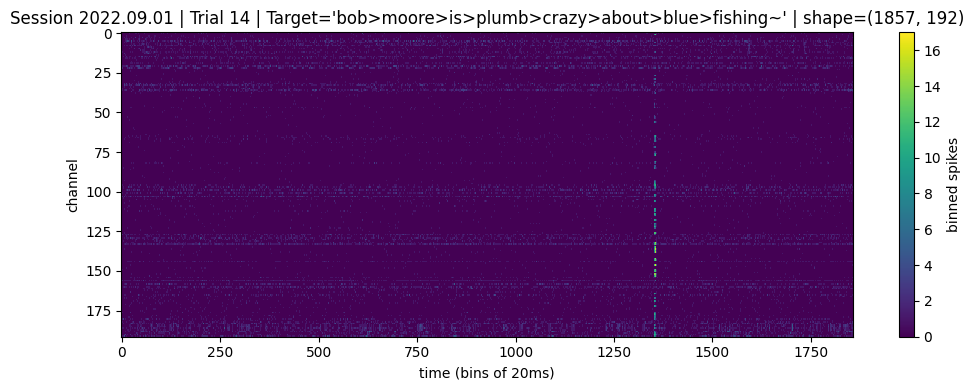

In [4]:
# Pick a representative file
files = sorted(held_in_dir.glob("*.nwb"))
if len(files) > 0:
    # pick the middle file for visualization
    fn = files[len(files) // 2]
    spikes, targets, trial_done, eval_mask = load_nwb(fn, dataset=FalconTask.h2)
    slices = segment_trials(trial_done)
    if slices:
        lengths = np.array([slc.stop - slc.start for slc in slices])
        mid_idx = int(np.argsort(lengths)[len(lengths)//2])
        slc = slices[mid_idx]
        trial_spikes = spikes[slc]
        text = decode_target_codes(targets[mid_idx]) if mid_idx < len(targets) else ""
        session = infer_session_from_name(fn.stem)
        plt.figure(figsize=(10,4))
        plt.imshow(trial_spikes.T, aspect='auto', interpolation='nearest', cmap='viridis')
        plt.colorbar(label='binned spikes')
        plt.xlabel('time (bins of 20ms)')
        plt.ylabel('channel')
        plt.title(f"Session {session} | Trial {mid_idx} | Target='{text}' | shape={trial_spikes.shape}")
        plt.tight_layout()
        plt.show()
    else:
        print("No trials found in selected file.")
else:
    print("No held_in_calib files found for visualization.")

## 5) Define Metrics (WER, CER, Normalized Latency)

We implement edit-distance based WER and CER for sanity checks. The evaluator will also report metrics including normalized latency.



Formulas:



- $WER = \frac{S + D + I}{N}$, where $S$=substitutions, $D$=deletions, $I$=insertions, $N$=number of reference words.

- $CER = \frac{S + D + I}{N_{char}}$, with counts at the character level.


In [5]:
# Simple edit distance and WER/CER helpers

def _edit_distance(a, b):

    # dynamic programming Levenshtein distance

    n, m = len(a), len(b)

    if n == 0:

        return m

    if m == 0:

        return n

    dp = np.zeros((n+1, m+1), dtype=int)

    dp[0, :] = np.arange(m+1)

    dp[:, 0] = np.arange(n+1)

    for i in range(1, n+1):

        for j in range(1, m+1):

            cost = 0 if a[i-1] == b[j-1] else 1

            dp[i, j] = min(

                dp[i-1, j] + 1,      # deletion

                dp[i, j-1] + 1,      # insertion

                dp[i-1, j-1] + cost  # substitution

            )

    return dp[n, m]



def compute_wer(ref: str, hyp: str) -> float:

    ref_words = ref.strip().split()

    hyp_words = hyp.strip().split()

    N = max(1, len(ref_words))

    return _edit_distance(ref_words, hyp_words) / N



def compute_cer(ref: str, hyp: str) -> float:

    ref_chars = list(ref)

    hyp_chars = list(hyp)

    N = max(1, len(ref_chars))

    return _edit_distance(ref_chars, hyp_chars) / N


## 6) Train Hritik Decoder on Held-In Calib

We train a lightweight configuration by default (few epochs) so it can run on CPU. Increase epochs/batch size for better performance.

In [6]:
# Training (runs JAX). Set device to 'cpu' or 'cuda' by changing JAX_PLATFORMS above.
import importlib
import decoder_demos.hritik_decoder as hdec
hdec = importlib.reload(hdec)
from decoder_demos.hritik_decoder import train_hritik, HritikConfig, TrainConfig
from decoder_demos.hritik_decoder import inspect_decoder_distributions


save_base = model_out / "model"

# Temporal-aware configuration with higher capacity, latent self-attention, and CLS pooling.
# Decoder config is reused at inference time so we keep a single shared instance.
decoder_cfg = HritikConfig(
    d_model=256,
    n_latents=32,
    d_latent=256,
    dec_hidden=512,
    dec_embed=256,
    autoregressive=True,
    beam_size=1,             # rely on sampling with repeat blocking
    len_penalty=0.0,         # let sequence length emerge naturally
    rep_penalty=1.3,         # discourage immediate repeats
    temperature=0.7,         # sharpen logits for sampling
    top_k=8,
    top_p=0.9,
    max_repeat=3,
    diversity_penalty=3.0,   # heavy penalty if a char would exceed repeat limit
    max_time_bins=256,
    time_downsample=4,
    label_smoothing=0.05,
    entropy_bonus=0.0,
    latent_noise_std=0.01,
    enable_latent_transformer=True,
    transformer_layers=3,
    transformer_heads=8,
    transformer_ff_mult=4.0,
    dropout_rate=0.1,
    use_cls_token=True,
    rotary_freq_base=10000.0,
 )

tcfg = TrainConfig(
    epochs=100,
    batch_size=8,
    lr=5e-4,
    max_len=48,)

print("Starting training on held_in_calib…")
print(f"Training for {tcfg.epochs} epochs (~{tcfg.epochs*3} seconds on CPU)")
print("Watch the loss - it should decrease from ~4 to <1.0 for decent performance")
print("Note: This may take a while. Consider reducing epochs if you want faster iteration.")
# train_hritik reads NWB files from held_in_dir; no need to pass spike arrays here
train_hritik(held_in_dir, None, save_base, decoder_cfg, tcfg)
print("Training complete. Checkpoint saved under:", save_base.with_suffix(".arrays.npz"))

Starting training on held_in_calib…
Training for 100 epochs (~300 seconds on CPU)
Watch the loss - it should decrease from ~4 to <1.0 for decent performance
Note: This may take a while. Consider reducing epochs if you want faster iteration.


Epoch 100/100: 100%|██████████| 84/84 [00:03<00:00, 22.34it/s, loss=0.398]



Saved model arrays to /Users/hritikarasu/Developer/falcon-challenge/local_data/hritik_h2/model.arrays.npz
Training complete. Checkpoint saved under: /Users/hritikarasu/Developer/falcon-challenge/local_data/hritik_h2/model.arrays.npz


## Inspect decoder distributions (optional)

After training and loading the decoder below, run this cell to quantify attention entropy and token confidence for a representative trial. High average top-1 probability coupled with low entropy can indicate collapsed sampling.

In [7]:
# Use a saved decoder (dec) or build a fresh one if needed
from decoder_demos.hritik_decoder import HritikDecoder  # Ensure HritikDecoder is imported

if 'dec' not in globals():
    task = FalconTask.h2
    task_cfg = FalconConfig(task=task)
    save_base = model_out / "model"
    dec = HritikDecoder(task_config=task_cfg, model_path=str(save_base), batch_size=1)

sample_files = sorted(minival_dir.glob("*.nwb"))
if not sample_files:
    raise RuntimeError("No minival files available for diagnostics.")
sample_fn = sample_files[0]
spikes, targets, trial_done, _ = load_nwb(sample_fn, dataset=FalconTask.h2)
trial_slices = segment_trials(trial_done)
if not trial_slices:
    raise RuntimeError("Trial boundaries not found in the selected file.")
trial_idx = 0
trial_slice = trial_slices[trial_idx]
trial_spikes = spikes[trial_slice]
session_tag = infer_session_from_name(sample_fn.stem)
stats = inspect_decoder_distributions(dec, trial_spikes, session_id=session_tag)
print("Diagnostics for", sample_fn.name)
print(json.dumps(stats, indent=2))

Diagnostics for sub-T5-held-in-minival_ses-20220518.nwb
{
  "attention_entropy": 5.544943332672119,
  "avg_token_entropy": 3.3077002614736557,
  "avg_top1_prob": 0.09494749751562874,
  "steps": 48.0
}


## 7) Local Minival Evaluation with FalconEvaluator

We instantiate the decoder from the saved checkpoint and evaluate on `minival` locally. We'll display WER/CER and normalized latency if provided.

In [8]:
from falcon_challenge.evaluator import FalconEvaluator
from decoder_demos.hritik_decoder import HritikDecoder

if "decoder_cfg" not in globals():
    decoder_cfg = HritikConfig(
        enable_latent_transformer=True,
        transformer_layers=3,
        transformer_heads=8,
        use_cls_token=True,
    )

# Build decoder from saved checkpoint and evaluate on minival
task = FalconTask.h2
task_cfg = FalconConfig(task=task)
save_base = model_out / "model"  # ensure save_base is defined
dec = HritikDecoder(task_config=task_cfg, model_path=str(save_base), batch_size=1, cfg=decoder_cfg)

evaluator = FalconEvaluator(eval_remote=False, split="h2")
res = evaluator.evaluate(decoder=dec, phase="minival")

print("Evaluator results:")
print(res)

# Extract metrics robustly across different result formats
# Expected (current) shape from evaluator:
#   {
#     'result': [{'minival_split_h2': { 'Normalized Latency': ..., 'Held In WER': ..., 'Held In CER': ... }}],
#     'submission_result': {'minival_split_h2': { 'Normalized Latency': ..., 'Held In WER': ..., 'Held In CER': ... }}
#   }
# Legacy fallback keys (not used here but supported): 'H2' -> {'WER_mean','CER_mean','NormalizedLatency'}
def extract_metrics(res_dict):
    # Prefer submission_result, then result[0]
    block = None
    sr = res_dict.get("submission_result")
    if isinstance(sr, dict):
        block = sr.get("minival_split_h2")
        if block is None:
            # pick first dict-valued entry if the key name differs
            for v in sr.values():
                if isinstance(v, dict):
                    block = v
                    break
    if block is None:
        rlist = res_dict.get("result")
        if isinstance(rlist, list) and rlist:
            first = rlist[0]
            if isinstance(first, dict):
                block = first.get("minival_split_h2")
                if block is None:
                    for v in first.values():
                        if isinstance(v, dict):
                            block = v
                            break
    if isinstance(block, dict):
        lat = block.get("Normalized Latency")
        wer = block.get("Held In WER")
        cer = block.get("Held In CER")
        return wer, cer, lat
    # Fallback legacy keys
    H2 = res_dict.get("H2", {})
    wer = H2.get("WER_mean", res_dict.get("WER_mean"))
    cer = H2.get("CER_mean", res_dict.get("CER_mean"))
    lat = H2.get("NormalizedLatency", res_dict.get("NormalizedLatency"))
    return wer, cer, lat

wer, cer, lat = extract_metrics(res)
print(f"WER_mean: {wer}")
print(f"CER_mean: {cer}")
print(f"NormalizedLatency: {lat}")

INFO:falcon_challenge.evaluator:Searching for evaluation data.
INFO:falcon_challenge.evaluator:Found 21 files.
INFO:falcon_challenge.evaluator:Found 21 files.


Found: [PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220518.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220523.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220525.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220601.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220603.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220606.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220608.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220613.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220615.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220622.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220901.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-

100%|██████████| 21/21 [00:14<00:00,  1.48it/s]

INFO:falcon_challenge.evaluator:Evaluation: Docker side
INFO:falcon_challenge.evaluator:Loading GT from ./local_gt.pkl
INFO:falcon_challenge.evaluator:Loading submission from ./local_prediction.pkl
INFO:falcon_challenge.evaluator:Phase: minival
INFO:falcon_challenge.evaluator:Evaluation: Docker side
INFO:falcon_challenge.evaluator:Loading GT from ./local_gt.pkl
INFO:falcon_challenge.evaluator:Loading submission from ./local_prediction.pkl
INFO:falcon_challenge.evaluator:Phase: minival


Returning result from phase: minival: [{'minival_split_h2': {'Normalized Latency': np.float64(1.989344649657032e-05), 'Held In WER': np.float64(1.2296045787144858), 'Held In CER': np.float64(1.3519928453830037), 'Held In WER Std.': np.float64(0.745293391195095), 'Held In CER Std.': np.float64(1.0503940233823728)}}]
Evaluator results:
{'result': [{'minival_split_h2': {'Normalized Latency': np.float64(1.989344649657032e-05), 'Held In WER': np.float64(1.2296045787144858), 'Held In CER': np.float64(1.3519928453830037), 'Held In WER Std.': np.float64(0.745293391195095), 'Held In CER Std.': np.float64(1.0503940233823728)}}], 'submission_result': {'minival_split_h2': {'Normalized Latency': np.float64(1.989344649657032e-05), 'Held In WER': np.float64(1.2296045787144858), 'Held In CER': np.float64(1.3519928453830037), 'Held In WER Std.': np.float64(0.745293391195095), 'Held In CER Std.': np.float64(1.0503940233823728)}}}
WER_mean: 1.2296045787144858
CER_mean: 1.3519928453830037
NormalizedLatenc

## 8) Manual WER/CER Sanity Check from Predictions

We stream `minival` spikes through the decoder step-by-step, calling `on_done` when a trial ends, and compute aggregate WER/CER with the helpers above.

In [9]:
refs, hyps, diagnostics = [], [], []

dec.reset()

for fn in sorted(minival_dir.glob("*.nwb")):
    spikes, targets, trial_done, _ = load_nwb(fn, dataset=FalconTask.h2)
    trial_slices = segment_trials(trial_done)
    if not trial_slices:
        continue
    # Reset with dataset tag so decoder can set session context if needed
    dec.reset([fn])
    session_tag = infer_session_from_name(fn.stem)
    tgt_strings = [decode_target_codes(arr).lower() for arr in targets[: len(trial_slices)]]
    for idx, slc in enumerate(trial_slices):
        trial_spikes = spikes[slc]
        for t in range(slc.start, slc.stop):
            dec.predict(spikes[t : t + 1, :])
        hyp = dec.on_done(np.array([True]))
        hyps.append(hyp)
        ref_text = tgt_strings[idx] if idx < len(tgt_strings) else ""
        refs.append(ref_text)
        try:
            diag = inspect_decoder_distributions(dec, trial_spikes, session_id=session_tag)
        except Exception as diag_err:
            diag = {
                "attention_entropy": float("nan"),
                "avg_token_entropy": float("nan"),
                "avg_top1_prob": float("nan"),
                "steps": float("nan"),
                "error": str(diag_err),
            }
        diagnostics.append(diag)

# Align lengths (just in case)
n = min(len(refs), len(hyps))
refs = refs[:n]
hyps = hyps[:n]
diagnostics = diagnostics[:n]

agg_wer = np.mean([compute_wer(r, h) for r, h in zip(refs, hyps)]) if n > 0 else float("nan")
agg_cer = np.mean([compute_cer(r, h) for r, h in zip(refs, hyps)]) if n > 0 else float("nan")
print(f"Manual minival WER: {agg_wer}")
print(f"Manual minival CER: {agg_cer}")
print(f"Compared to evaluator above (they may differ slightly due to protocol details).")

valid_token_entropy = [d.get("avg_token_entropy") for d in diagnostics if isinstance(d.get("avg_token_entropy"), (int, float))]
valid_top1 = [d.get("avg_top1_prob") for d in diagnostics if isinstance(d.get("avg_top1_prob"), (int, float))]
valid_steps = [d.get("steps") for d in diagnostics if isinstance(d.get("steps"), (int, float))]
decoder_diag_summary = {
    "trials": n,
    "avg_token_entropy": float(np.nanmean(valid_token_entropy)) if valid_token_entropy else float("nan"),
    "avg_top1_prob": float(np.nanmean(valid_top1)) if valid_top1 else float("nan"),
    "avg_generated_steps": float(np.nanmean(valid_steps)) if valid_steps else float("nan"),
}

Manual minival WER: 1.0
Manual minival CER: 1.53632740164259
Compared to evaluator above (they may differ slightly due to protocol details).


### Sample Predictions: Actual vs Predicted

Let's inspect a sample of actual reference texts vs model predictions to see if the model is learning meaningful patterns or just failing to produce coherent outputs.

In [10]:
# Display first 15 samples of actual vs predicted
print("="*80)
print("SAMPLE PREDICTIONS (first 15 trials from minival)")
print("="*80)
n_samples = min(15, len(refs))
for i in range(n_samples):
    ref_text = refs[i]
    hyp_text = hyps[i]
    trial_wer = compute_wer(ref_text, hyp_text)
    trial_cer = compute_cer(ref_text, hyp_text)
    
    print(f"\nTrial {i+1}:")
    print(f"  Reference: '{ref_text}'")
    print(f"  Predicted: '{hyp_text}'")
    print(f"  WER: {trial_wer:.3f} | CER: {trial_cer:.3f}")
    print("-"*80)

# Summary statistics
empty_preds = sum(1 for h in hyps if len(h.strip()) == 0)
short_preds = sum(1 for h in hyps if 0 < len(h.strip()) < 3)
mean_trial_wer = np.mean([compute_wer(r, h) for r, h in zip(refs, hyps)]) if hyps else float("nan")
mean_trial_cer = np.mean([compute_cer(r, h) for r, h in zip(refs, hyps)]) if hyps else float("nan")
print(f"\n{'='*80}")
print(f"SUMMARY STATISTICS (all {len(hyps)} trials)")
print(f"{'='*80}")
print(f"Empty predictions: {empty_preds}/{len(hyps)} ({100*empty_preds/max(1,len(hyps)):.1f}%)")
print(f"Very short predictions (<3 chars): {short_preds}/{len(hyps)} ({100*short_preds/max(1,len(hyps)):.1f}%)")
print(f"Average reference length: {np.mean([len(r) for r in refs]):.1f} chars")
print(f"Average prediction length: {np.mean([len(h) for h in hyps]):.1f} chars")
print(f"Mean per-trial WER: {mean_trial_wer:.3f}")
print(f"Mean per-trial CER: {mean_trial_cer:.3f}")

if isinstance(globals().get("decoder_diag_summary"), dict) and decoder_diag_summary.get("trials", 0):
    tok_entropy = decoder_diag_summary.get("avg_token_entropy", float("nan"))
    top1_prob = decoder_diag_summary.get("avg_top1_prob", float("nan"))
    avg_steps = decoder_diag_summary.get("avg_generated_steps", float("nan"))
    print(f"Decoder avg token entropy: {tok_entropy:.3f}")
    print(f"Decoder avg top-1 prob: {top1_prob:.3f}")
    print(f"Decoder avg generated steps: {avg_steps:.1f}")
    if np.isfinite(top1_prob) and top1_prob > 0.9:
        print("Warning: Decoder is extremely confident in a single character; consider increasing beam search, lowering rep_penalty, or revisiting training.")
    if np.isfinite(avg_steps) and avg_steps < 5:
        print("Warning: Decoder is stopping very early; verify transformer latents and sampling penalties.")

SAMPLE PREDICTIONS (first 15 trials from minival)

Trial 1:
  Reference: 'there>just>might>be>too>many>people>there~'
  Predicted: ',aivaqa,pibj,v,bv,apv,v,vj,vajaqapapvaiqvj,aji,a'
  WER: 1.000 | CER: 1.071
--------------------------------------------------------------------------------

Trial 2:
  Reference: 'he>was>an>important>man>in>his>village~'
  Predicted: 't,aqa,apajavajavjbaj,qpiapj,qpjqjpa,bipapjvibjav'
  WER: 1.000 | CER: 1.077
--------------------------------------------------------------------------------

Trial 3:
  Reference: 'stay>home'
  Predicted: ',apa,pvaipibapaqavp,vaqbvqapqvpj,vpjp,qapaivpa,p'
  WER: 1.000 | CER: 5.222
--------------------------------------------------------------------------------

Trial 4:
  Reference: 'no>cash'
  Predicted: 'vavaqpbqvpbpvip,iqiaqajava,baqivaipbvp,v,vqjavap'
  WER: 1.000 | CER: 6.714
--------------------------------------------------------------------------------

Trial 5:
  Reference: 'keep>it'
  Predicted: 'xpvbvavabjajaja,aj

## 9) Few-Shot Recalibration on Held-Out Calib (Optional)

You can try a short run on `held_out_calib` to simulate few-shot recalibration, then evaluate the new checkpoint.

In [11]:
# Optional: few-shot training on held-out calib, then evaluate

if "decoder_cfg" not in globals():
    decoder_cfg = HritikConfig()

fewshot_save = project_root / "local_data" / "hritik_h2_fewshot" / "model"
fewshot_save.parent.mkdir(parents=True, exist_ok=True)

# Keep epochs tiny for demonstration
tcfg_few = TrainConfig(epochs=1, batch_size=8, lr=1e-3, max_len=48)
print("Starting few-shot training on held_out_calib…")
train_hritik(held_out_dir, None, fewshot_save, decoder_cfg, tcfg_few)

# Evaluate few-shot model on minival
dec_few = HritikDecoder(task_config=task_cfg, model_path=str(fewshot_save), batch_size=1, cfg=decoder_cfg)
res_few = evaluator.evaluate(decoder=dec_few, phase="minival")
print("Few-shot evaluator results:", res_few)

Starting few-shot training on held_out_calib…


Epoch 1/1: 100%|██████████| 2/2 [00:02<00:00,  1.13s/it, loss=3.33]

INFO:falcon_challenge.evaluator:Searching for evaluation data.
INFO:falcon_challenge.evaluator:Found 21 files.
INFO:falcon_challenge.evaluator:Searching for evaluation data.
INFO:falcon_challenge.evaluator:Found 21 files.


Saved model arrays to /Users/hritikarasu/Developer/falcon-challenge/local_data/hritik_h2_fewshot/model.arrays.npz
Found: [PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220518.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220523.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220525.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220601.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220603.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220606.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220608.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220613.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220615.nwb'), PosixPath('data/h2/sub-T5-held-in-minival/sub-T5-held-in-minival_ses-20220622.nwb'), PosixPath('data/h2/sub-T5-he

100%|██████████| 21/21 [00:12<00:00,  1.72it/s]

INFO:falcon_challenge.evaluator:Evaluation: Docker side
INFO:falcon_challenge.evaluator:Loading GT from ./local_gt.pkl
INFO:falcon_challenge.evaluator:Loading submission from ./local_prediction.pkl
INFO:falcon_challenge.evaluator:Phase: minival
INFO:falcon_challenge.evaluator:Evaluation: Docker side
INFO:falcon_challenge.evaluator:Loading GT from ./local_gt.pkl
INFO:falcon_challenge.evaluator:Loading submission from ./local_prediction.pkl
INFO:falcon_challenge.evaluator:Phase: minival


Returning result from phase: minival: [{'minival_split_h2': {'Normalized Latency': np.float64(1.974022118866443e-05), 'Held In WER': np.float64(1.2296045787144858), 'Held In CER': np.float64(1.3519928453830037), 'Held In WER Std.': np.float64(0.745293391195095), 'Held In CER Std.': np.float64(1.0503940233823728)}}]
Few-shot evaluator results: {'result': [{'minival_split_h2': {'Normalized Latency': np.float64(1.974022118866443e-05), 'Held In WER': np.float64(1.2296045787144858), 'Held In CER': np.float64(1.3519928453830037), 'Held In WER Std.': np.float64(0.745293391195095), 'Held In CER Std.': np.float64(1.0503940233823728)}}], 'submission_result': {'minival_split_h2': {'Normalized Latency': np.float64(1.974022118866443e-05), 'Held In WER': np.float64(1.2296045787144858), 'Held In CER': np.float64(1.3519928453830037), 'Held In WER Std.': np.float64(0.745293391195095), 'Held In CER Std.': np.float64(1.0503940233823728)}}}
